<a href="https://colab.research.google.com/github/apurbacse18-spec/digital-forensics-investigation-report/blob/main/00_environment_setup.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Email Spam Detection Project
 – Hands-on Machine Learning Pipeline

In [ ]:
import sys
print(sys.version)

!pip install numpy pandas matplotlib scikit-learn

import os

base_path = "/content/email-spam-detection"

folders = ["data", "notebooks", "src", "reports"]

for folder in folders:
    os.makedirs(os.path.join(base_path, folder), exist_ok=True)

os.listdir(base_path)

3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]


['reports', 'data', 'notebooks', 'src']

## Step 3: Dataset Acquisition and Integrity Verification

In [ ]:
import os
import urllib.request

# Where to save the dataset
dataset_url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00228/smsspamcollection.zip"
zip_path = os.path.join(base_path, "data", "smsspamcollection.zip")

# Download
urllib.request.urlretrieve(dataset_url, zip_path)

# Basic checks
print("Downloaded to:", zip_path)
print("File exists:", os.path.exists(zip_path))
print("File size (bytes):", os.path.getsize(zip_path))

Downloaded to: /content/email-spam-detection/data/smsspamcollection.zip
File exists: True
File size (bytes): 203415


## Step 3.2: Verify and Extract Dataset


In [ ]:
import hashlib
import zipfile
import os

# 1) Compute SHA-256 hash (integrity fingerprint)
def sha256_file(path, chunk_size=8192):
    h = hashlib.sha256()
    with open(path, "rb") as f:
        for chunk in iter(lambda: f.read(chunk_size), b""):
            h.update(chunk)
    return h.hexdigest()

sha256 = sha256_file(zip_path)
print("SHA-256:", sha256)

# 2) Extract safely into data/ folder
extract_path = os.path.join(base_path, "data", "smsspamcollection")
os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile(zip_path, "r") as z:
    z.extractall(extract_path)

print("Extracted to:", extract_path)
print("Files:", os.listdir(extract_path))

SHA-256: 1587ea43e58e82b14ff1f5425c88e17f8496bfcdb67a583dbff9eefaf9963ce3
Extracted to: /content/email-spam-detection/data/smsspamcollection
Files: ['SMSSpamCollection', 'readme']


## Step 3.3: Load Raw Dataset and Create Clean CSV


In [ ]:
import os
import pandas as pd

# Path to extracted raw file
raw_path = os.path.join(base_path, "data", "smsspamcollection", "SMSSpamCollection")

# Load: each line is "label<TAB>message"
df = pd.read_csv(raw_path, sep="\t", header=None, names=["label", "text"], encoding="utf-8")

# Quick verification outputs
print("Shape:", df.shape)
print("Labels:", df["label"].unique())
print("\nLabel counts:\n", df["label"].value_counts())

# Save clean CSV for the rest of the project
clean_csv_path = os.path.join(base_path, "data", "sms_spam.csv")
df.to_csv(clean_csv_path, index=False)

print("\nSaved clean CSV to:", clean_csv_path)
df.head()

Shape: (5572, 2)
Labels: ['ham' 'spam']

Label counts:
 label
ham     4825
spam     747
Name: count, dtype: int64

Saved clean CSV to: /content/email-spam-detection/data/sms_spam.csv


,label,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


## Step 4: Rule-Based Baseline Spam Detector


In [ ]:

import os
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Load clean dataset
csv_path = os.path.join(base_path, "data", "sms_spam.csv")
df = pd.read_csv(csv_path)

# Baseline keywords (simple + interpretable)
keywords = ["buy", "sex"]

# Feature: count occurrences of each keyword
for kw in keywords:
    df[kw] = df["text"].str.lower().str.count(kw)

# Score: sum of counts
df["score"] = df[keywords].sum(axis=1)

# Rule-based prediction: score > 0 => spam else ham
df["rule_pred"] = df["score"].apply(lambda s: "spam" if s > 0 else "ham")

# Train/test split for evaluation (stratify keeps label balance)
train_df, test_df = train_test_split(
    df, test_size=0.30, random_state=42, stratify=df["label"]
)

y_true = test_df["label"]
y_pred = test_df["rule_pred"]

print("Keywords:", keywords)
print("Test accuracy:", accuracy_score(y_true, y_pred))

print("\nConfusion matrix (rows=true, cols=pred) [ham, spam]:")
print(confusion_matrix(y_true, y_pred, labels=["ham", "spam"]))

print("\nClassification report:")
print(classification_report(y_true, y_pred, labels=["ham", "spam"]))


Keywords: ['buy', 'sex']
Test accuracy: 0.8606459330143541

Confusion matrix (rows=true, cols=pred) [ham, spam]:
[[1428   20]
 [ 213   11]]

Classification report:
              precision    recall  f1-score   support

         ham       0.87      0.99      0.92      1448
        spam       0.35      0.05      0.09       224

    accuracy                           0.86      1672
   macro avg       0.61      0.52      0.51      1672
weighted avg       0.80      0.86      0.81      1672



## Step 4.2: Improved Rule-Based Filter (Weighted Keywords + Threshold)
``

In [ ]:
import os
import operator
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report, f1_score
)

# -----------------------------
# Load clean dataset
# -----------------------------
csv_path = os.path.join(base_path, "data", "sms_spam.csv")
df = pd.read_csv(csv_path)

# Ensure text/label are always strings
df["text"] = df["text"].fillna("").astype(str)
df["label"] = df["label"].fillna("").astype(str)

# -----------------------------
# Improved keyword list (more realistic spam indicators)
# -----------------------------
keywords = [
    "free", "win", "winner", "prize", "cash", "claim",
    "urgent", "call", "txt", "text", "reply", "stop",
    "credit", "loan", "offer", "buy", "sex", "click",
    "www", "http", "link"
]

# Weights for keywords (stronger indicators => larger weight)
weights = {
    "free": 2, "win": 2, "winner": 3, "prize": 3, "cash": 2, "claim": 3,
    "urgent": 3, "call": 1, "txt": 1, "text": 1, "reply": 1, "stop": 1,
    "credit": 2, "loan": 2, "offer": 2, "buy": 1, "sex": 2, "click": 3,
    "www": 2, "http": 2, "link": 2
}

# -----------------------------
# Feature engineering (keyword counts)
# -----------------------------
text_lower = df["text"].str.lower()

for kw in keywords:
    df[kw] = text_lower.str.count(kw)

# Weighted score
df["wscore"] = 0
for kw in keywords:
    df["wscore"] += df[kw] * weights[kw]

# -----------------------------
# Train/test split (stratified)
# -----------------------------
train_df, test_df = train_test_split(
    df, test_size=0.30, random_state=42, stratify=df["label"]
)

# -----------------------------
# Threshold tuning on TRAIN only
# Optimize spam F1 to reduce false negatives
# -----------------------------
thresholds = list(range(0, 21))
best_t = None
best_f1 = -1.0

for t in thresholds:
    # Use np.greater instead of ">"
    train_is_spam = np.greater(train_df["wscore"].values, t)
    train_pred = np.where(train_is_spam, "spam", "ham")

    f1 = f1_score(train_df["label"], train_pred, pos_label="spam")

    # Use operator.gt instead of ">"
    if operator.gt(f1, best_f1):
        best_f1 = f1
        best_t = t

print("Best threshold (train):", best_t)
print("Best spam F1 (train):", best_f1)

# -----------------------------
# Evaluate on TEST using best threshold
# -----------------------------
test_is_spam = np.greater(test_df["wscore"].values, best_t)
test_pred = np.where(test_is_spam, "spam", "ham")

print("\nTEST accuracy:", accuracy_score(test_df["label"], test_pred))

print("\nConfusion matrix (rows=true, cols=pred) [ham, spam]:")
print(confusion_matrix(test_df["label"], test_pred, labels=["ham", "spam"]))

print("\nClassification report:")
print(classification_report(test_df["label"], test_pred, labels=["ham", "spam"]))

Best threshold (train): 2
Best spam F1 (train): 0.7713675213675214

TEST accuracy: 0.9491626794258373

Confusion matrix (rows=true, cols=pred) [ham, spam]:
[[1434   14]
 [  71  153]]

Classification report:
              precision    recall  f1-score   support

         ham       0.95      0.99      0.97      1448
        spam       0.92      0.68      0.78       224

    accuracy                           0.95      1672
   macro avg       0.93      0.84      0.88      1672
weighted avg       0.95      0.95      0.95      1672



## Step 5: Perceptron Model (Keyword Feature Vector)
``

In [ ]:
import os
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Perceptron
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Load dataset
csv_path = os.path.join(base_path, "data", "sms_spam.csv")
df = pd.read_csv(csv_path)

# Ensure clean types
df["text"] = df["text"].fillna("").astype(str)
df["label"] = df["label"].fillna("").astype(str)

# Use the same improved keyword list as Step 4.2
keywords = [
    "free", "win", "winner", "prize", "cash", "claim",
    "urgent", "call", "txt", "text", "reply", "stop",
    "credit", "loan", "offer", "buy", "sex", "click",
    "www", "http", "link"
]

# Build keyword-count feature matrix X
text_lower = df["text"].str.lower()
for kw in keywords:
    df[kw] = text_lower.str.count(kw)

X = df[keywords].values

# Encode labels for Perceptron: spam=-1, ham=+1 (matches slide style)
y = np.where(df["label"].values == "spam", -1, 1)

# Split (stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=df["label"]
)

# Train Perceptron
clf = Perceptron(max_iter=1000, eta0=0.1, random_state=42, tol=1e-3)
clf.fit(X_train, y_train)

# Predict
y_pred = clf.predict(X_test)

# Convert back to text labels for reporting
y_test_lbl = np.where(y_test == -1, "spam", "ham")
y_pred_lbl = np.where(y_pred == -1, "spam", "ham")

print("Perceptron trained with", len(keywords), "features")
print("TEST accuracy:", accuracy_score(y_test_lbl, y_pred_lbl))

print("\nConfusion matrix (rows=true, cols=pred) [ham, spam]:")
print(confusion_matrix(y_test_lbl, y_pred_lbl, labels=["ham", "spam"]))

print("\nClassification report:")
print(classification_report(y_test_lbl, y_pred_lbl, labels=["ham", "spam"]))

Perceptron trained with 21 features
TEST accuracy: 0.9324162679425837

Confusion matrix (rows=true, cols=pred) [ham, spam]:
[[1396   52]
 [  61  163]]

Classification report:
              precision    recall  f1-score   support

         ham       0.96      0.96      0.96      1448
        spam       0.76      0.73      0.74       224

    accuracy                           0.93      1672
   macro avg       0.86      0.85      0.85      1672
weighted avg       0.93      0.93      0.93      1672



## Step 5.2: Perceptron Explainability (Learned Feature Weights)
``

Bias (intercept): 0.20000000000000004

Top 10 spam-indicating keywords (highest positive weights):
keyword        weight
   link  1.000000e-01
    buy  2.775558e-17
    sex -2.775558e-17
    win -2.775558e-17
   call -1.000000e-01
   loan -1.000000e-01
  offer -1.000000e-01
   stop -1.000000e-01
   cash -1.000000e-01
 credit -1.000000e-01

Top 10 ham-indicating keywords (most negative weights):
keyword  weight
   http    -0.6
  prize    -0.5
  claim    -0.5
 winner    -0.4
   free    -0.3
  click    -0.2
    www    -0.2
    txt    -0.2
   text    -0.2
  reply    -0.1

Saved weights to: /content/email-spam-detection/reports/perceptron_feature_weights.csv


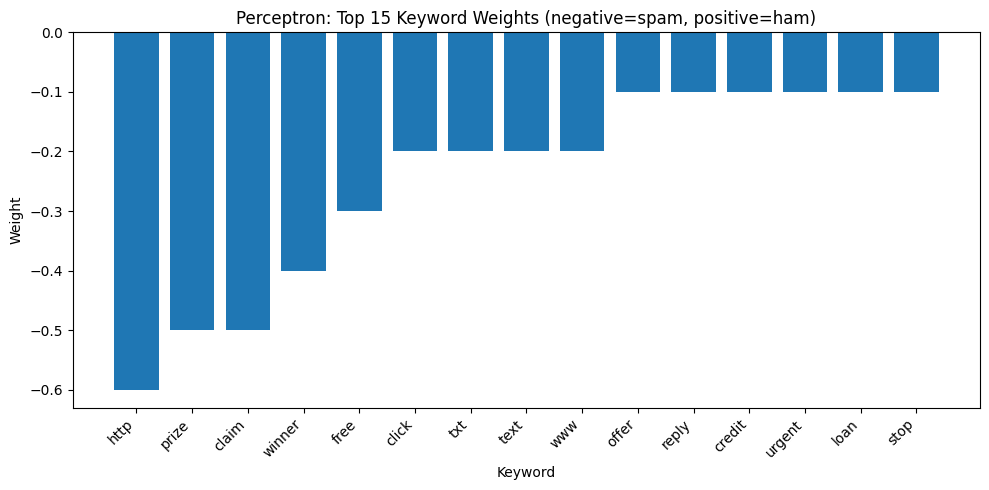

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Extract weights (Perceptron is a linear model)
weights = clf.coef_.ravel()
bias = float(clf.intercept_[0])

weights_df = pd.DataFrame({
    "keyword": keywords,
    "weight": weights
}).sort_values("weight", ascending=False)

print("Bias (intercept):", bias)
print("\nTop 10 spam-indicating keywords (highest positive weights):")
print(weights_df.head(10).to_string(index=False))

print("\nTop 10 ham-indicating keywords (most negative weights):")
print(weights_df.tail(10).sort_values("weight").to_string(index=False))

# Save to reports/ for GitHub
out_path = os.path.join(base_path, "reports", "perceptron_feature_weights.csv")
weights_df.to_csv(out_path, index=False)
print("\nSaved weights to:", out_path)

# Plot top absolute weights for visual explainability
weights_df["abs_weight"] = weights_df["weight"].abs()
top_abs = weights_df.sort_values("abs_weight", ascending=False).head(15)

plt.figure(figsize=(10, 5))
plt.bar(top_abs["keyword"], top_abs["weight"])
plt.xticks(rotation=45, ha="right")
plt.title("Perceptron: Top 15 Keyword Weights (negative=spam, positive=ham)")
plt.xlabel("Keyword")
plt.ylabel("Weight")
plt.tight_layout()
plt.show()


## Step 6.1: Train and Evaluate a Linear SVM (Same 21 Keyword Features)
``

In [ ]:
import os
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Load dataset
csv_path = os.path.join(base_path, "data", "sms_spam.csv")
df = pd.read_csv(csv_path)

# Clean types
df["text"] = df["text"].fillna("").astype(str)
df["label"] = df["label"].fillna("").astype(str)

# Same keyword list as before (keep consistent for fair comparison)
keywords = [
    "free", "win", "winner", "prize", "cash", "claim",
    "urgent", "call", "txt", "text", "reply", "stop",
    "credit", "loan", "offer", "buy", "sex", "click",
    "www", "http", "link"
]

# Build keyword-count features
text_lower = df["text"].str.lower()
for kw in keywords:
    df[kw] = text_lower.str.count(kw)

X = df[keywords].values
y = df["label"].values  # use string labels directly for SVM

# Split (stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

# Train Linear SVM
svm_clf = SVC(kernel="linear", C=1.0)
svm_clf.fit(X_train, y_train)

# Predict
y_pred = svm_clf.predict(X_test)

# Evaluate
acc = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred, labels=["ham", "spam"])
report = classification_report(y_test, y_pred, labels=["ham", "spam"])

print("SVM (linear) trained with", len(keywords), "features")
print("TEST accuracy:", acc)

print("\nConfusion matrix (rows=true, cols=pred) [ham, spam]:")
print(cm)

print("\nClassification report:")
print(report)

# Save results for GitHub/report
out_path = os.path.join(base_path, "reports", "svm_linear_results.txt")
with open(out_path, "w", encoding="utf-8") as f:
    f.write("SVM (linear) results\n")
    f.write(f"Accuracy: {acc}\n\n")
    f.write("Confusion matrix [ham, spam]:\n")
    f.write(np.array2string(cm))
    f.write("\n\nClassification report:\n")
    f.write(report)

print("\nSaved results to:", out_path)


SVM (linear) trained with 21 features
TEST accuracy: 0.9515550239234449

Confusion matrix (rows=true, cols=pred) [ham, spam]:
[[1437   11]
 [  70  154]]

Classification report:
              precision    recall  f1-score   support

         ham       0.95      0.99      0.97      1448
        spam       0.93      0.69      0.79       224

    accuracy                           0.95      1672
   macro avg       0.94      0.84      0.88      1672
weighted avg       0.95      0.95      0.95      1672


Saved results to: /content/email-spam-detection/reports/svm_linear_results.txt


## Step 6.2: Train and Evaluate an RBF (Non-Linear) SVM
``

In [ ]:
import os
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Load dataset
csv_path = os.path.join(base_path, "data", "sms_spam.csv")
df = pd.read_csv(csv_path)

df["text"] = df["text"].fillna("").astype(str)
df["label"] = df["label"].fillna("").astype(str)

keywords = [
    "free", "win", "winner", "prize", "cash", "claim",
    "urgent", "call", "txt", "text", "reply", "stop",
    "credit", "loan", "offer", "buy", "sex", "click",
    "www", "http", "link"
]

# Build keyword-count features
text_lower = df["text"].str.lower()
for kw in keywords:
    df[kw] = text_lower.str.count(kw)

X = df[keywords].values
y = df["label"].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

# RBF SVM pipeline (scale -> SVM)
rbf_svm = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(kernel="rbf", C=10.0, gamma="scale"))
])

rbf_svm.fit(X_train, y_train)
y_pred = rbf_svm.predict(X_test)

acc = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred, labels=["ham", "spam"])
report = classification_report(y_test, y_pred, labels=["ham", "spam"])

print("SVM (RBF) trained with", len(keywords), "features")
print("TEST accuracy:", acc)

print("\nConfusion matrix (rows=true, cols=pred) [ham, spam]:")
print(cm)

print("\nClassification report:")
print(report)

# Save results for GitHub/report
out_path = os.path.join(base_path, "reports", "svm_rbf_results.txt")
with open(out_path, "w", encoding="utf-8") as f:
    f.write("SVM (RBF) results\n")
    f.write(f"Accuracy: {acc}\n\n")
    f.write("Confusion matrix [ham, spam]:\n")
    f.write(np.array2string(cm))
    f.write("\n\nClassification report:\n")
    f.write(report)

print("\nSaved results to:", out_path)




SVM (RBF) trained with 21 features
TEST accuracy: 0.9539473684210527

Confusion matrix (rows=true, cols=pred) [ham, spam]:
[[1439    9]
 [  68  156]]

Classification report:
              precision    recall  f1-score   support

         ham       0.95      0.99      0.97      1448
        spam       0.95      0.70      0.80       224

    accuracy                           0.95      1672
   macro avg       0.95      0.85      0.89      1672
weighted avg       0.95      0.95      0.95      1672


Saved results to: /content/email-spam-detection/reports/svm_rbf_results.txt


## Step 7.1: TF-IDF Vectorization + Linear SVM (Baseline NLP Classifier)


In [ ]:
import os
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Load dataset
csv_path = os.path.join(base_path, "data", "sms_spam.csv")
df = pd.read_csv(csv_path)

# Clean types
df["text"] = df["text"].fillna("").astype(str)
df["label"] = df["label"].fillna("").astype(str)

X = df["text"].values
y = df["label"].values

# Split (stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

# Pipeline: TF-IDF -> Linear SVM
tfidf_svm = Pipeline([
    ("tfidf", TfidfVectorizer(
        lowercase=True,
        stop_words="english",
        ngram_range=(1, 2),   # unigrams + bigrams
        min_df=2              # ignore very rare terms
    )),
    ("svm", LinearSVC(random_state=42))
])

tfidf_svm.fit(X_train, y_train)
y_pred = tfidf_svm.predict(X_test)

acc = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred, labels=["ham", "spam"])
report = classification_report(y_test, y_pred, labels=["ham", "spam"])

print("TF-IDF + LinearSVC")
print("TEST accuracy:", acc)

print("\nConfusion matrix (rows=true, cols=pred) [ham, spam]:")
print(cm)

print("\nClassification report:")
print(report)

# Save results for GitHub/report
out_path = os.path.join(base_path, "reports", "tfidf_linear_svm_results.txt")
with open(out_path, "w", encoding="utf-8") as f:
    f.write("TF-IDF + LinearSVC results\n")
    f.write(f"Accuracy: {acc}\n\n")
    f.write("Confusion matrix [ham, spam]:\n")
    f.write(np.array2string(cm))
    f.write("\n\nClassification report:\n")
    f.write(report)

print("\nSaved results to:", out_path)

TF-IDF + LinearSVC
TEST accuracy: 0.9826555023923444

Confusion matrix (rows=true, cols=pred) [ham, spam]:
[[1444    4]
 [  25  199]]

Classification report:
              precision    recall  f1-score   support

         ham       0.98      1.00      0.99      1448
        spam       0.98      0.89      0.93       224

    accuracy                           0.98      1672
   macro avg       0.98      0.94      0.96      1672
weighted avg       0.98      0.98      0.98      1672


Saved results to: /content/email-spam-detection/reports/tfidf_linear_svm_results.txt


## Step 7.2: Explainability — Top TF-IDF Features for Spam vs Ham


In [ ]:
import os
import numpy as np
import pandas as pd

# Pull out fitted vectorizer + classifier from the pipeline
vectorizer = tfidf_svm.named_steps["tfidf"]
clf = tfidf_svm.named_steps["svm"]

feature_names = np.array(vectorizer.get_feature_names_out())
coefs = clf.coef_.ravel()  # weights for "spam" vs "ham" (binary linear SVM)

# In LinearSVC with string labels, coef_ corresponds to the second class in clf.classes_
# Let's confirm class order for correct interpretation
classes = clf.classes_
print("Class order (clf.classes_):", classes)

# If classes == ['ham','spam'], positive weights push toward 'spam'
# If reversed, interpretation flips.
spam_class_index = int(np.where(classes == "spam")[0][0])
ham_class_index = int(np.where(classes == "ham")[0][0])

# For binary LinearSVC, coefs represent separation; with classes ['ham','spam']:
# positive => spam, negative => ham
# We'll proceed with that common order but also print it clearly.
print("Interpretation:")
if list(classes) == ["ham", "spam"]:
    print("  Positive weight => SPAM-indicating feature")
    print("  Negative weight => HAM-indicating feature")
else:
    print("  NOTE: Class order is unusual; interpretation may be flipped.")

# Get top features
top_n = 20
top_spam_idx = np.argsort(coefs)[-top_n:][::-1]
top_ham_idx = np.argsort(coefs)[:top_n]

top_spam = pd.DataFrame({
    "feature": feature_names[top_spam_idx],
    "weight": coefs[top_spam_idx]
})

top_ham = pd.DataFrame({
    "feature": feature_names[top_ham_idx],
    "weight": coefs[top_ham_idx]
})

print("\nTop SPAM-indicating features:")
print(top_spam.to_string(index=False))

print("\nTop HAM-indicating features:")
print(top_ham.to_string(index=False))

# Save for GitHub/report
out_dir = os.path.join(base_path, "reports")
os.makedirs(out_dir, exist_ok=True)

top_spam_path = os.path.join(out_dir, "tfidf_top_spam_features.csv")
top_ham_path = os.path.join(out_dir, "tfidf_top_ham_features.csv")

top_spam.to_csv(top_spam_path, index=False)
top_ham.to_csv(top_ham_path, index=False)

print("\nSaved:")
print(" ", top_spam_path)
print(" ", top_ham_path)

Class order (clf.classes_): ['ham' 'spam']
Interpretation:
  Positive weight => SPAM-indicating feature
  Negative weight => HAM-indicating feature

Top SPAM-indicating features:
 feature   weight
      uk 2.326878
     txt 1.938035
  mobile 1.867220
   claim 1.850651
    150p 1.765697
     www 1.761207
   reply 1.529135
     com 1.512732
      50 1.499168
ringtone 1.427628
 service 1.424398
   video 1.412334
     new 1.393082
services 1.374702
   prize 1.340335
      18 1.266788
  dating 1.249443
      16 1.201803
   order 1.192477
     500 1.178935

Top HAM-indicating features:
   feature    weight
      road -0.791114
new number -0.743719
     gonna -0.711089
      home -0.679403
       got -0.631274
        lt -0.627995
       hey -0.623689
      mail -0.621452
        ok -0.602394
       yup -0.601973
       way -0.575503
     later -0.555788
  morphine -0.547301
      didn -0.545197
     liked -0.544677
 liked new -0.535325
     sorry -0.530769
       try -0.530036
      hope -0.

## Step 7.3: Error Analysis — Inspect Misclassified Messages

In [ ]:
import os
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

# Reload dataset (robust)
csv_path = os.path.join(base_path, "data", "sms_spam.csv")
df = pd.read_csv(csv_path)
df["text"] = df["text"].fillna("").astype(str)
df["label"] = df["label"].fillna("").astype(str)

X = df["text"].values
y = df["label"].values

# Same split as Step 7.1
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

# Predict using trained pipeline
y_pred = tfidf_svm.predict(X_test)

# Results dataframe
res = pd.DataFrame({"true_label": y_test, "pred_label": y_pred, "text": X_test})

false_pos = res[(res["true_label"] == "ham") & (res["pred_label"] == "spam")].copy()
false_neg = res[(res["true_label"] == "spam") & (res["pred_label"] == "ham")].copy()

print("Total test samples:", len(res))
print("False positives (ham→spam):", len(false_pos))
print("False negatives (spam→ham):", len(false_neg))

# Add simple helpful columns for analysis
false_pos["text_len"] = false_pos["text"].str.len()
false_neg["text_len"] = false_neg["text"].str.len()

print("\n--- False Positives (ALL, since only 4) ---")
print(false_pos[["true_label", "pred_label", "text_len", "text"]].to_string(index=False))

print("\n--- Sample False Negatives (first 10) ---")
print(false_neg[["true_label", "pred_label", "text_len", "text"]].head(10).to_string(index=False))

# Save to reports/
out_fp = os.path.join(base_path, "reports", "tfidf_false_positives.csv")
out_fn = os.path.join(base_path, "reports", "tfidf_false_negatives.csv")

false_pos.to_csv(out_fp, index=False)
false_neg.to_csv(out_fn, index=False)

print("\nSaved:")
print(" ", out_fp)
print(" ", out_fn)


Total test samples: 1672
False positives (ham→spam): 4
False negatives (spam→ham): 25

--- False Positives (ALL, since only 4) ---
true_label pred_label  text_len                                                  text
       ham       spam        25                             Msg me when rajini comes.
       ham       spam        25                             Ok... Ur typical reply...
       ham       spam        40              K..u also dont msg or reply to his msg..
       ham       spam        53 here is my new address -apples&pairs&all that malarky

--- Sample False Negatives (first 10) ---
true_label pred_label  text_len                                                                                                                                                            text
      spam        ham        24                                                                                                                                        FROM 88066 LOST £12 HELP
      spam  

## Step 7.4: Failure Pattern Labeling (Error Taxonomy)

In [ ]:
import os
import re
import pandas as pd
import numpy as np
from html import unescape

# Load misclassification files produced in Step 7.3
fp_path = os.path.join(base_path, "reports", "tfidf_false_positives.csv")
fn_path = os.path.join(base_path, "reports", "tfidf_false_negatives.csv")

false_pos = pd.read_csv(fp_path)
false_neg = pd.read_csv(fn_path)

# Safety: enforce strings
for d in (false_pos, false_neg):
    d["text"] = d["text"].fillna("").astype(str)

# Regex/pattern helpers (simple but effective)
url_re = re.compile(r"(https?://|www\.)\S+", re.IGNORECASE)
phone_re = re.compile(r"\b(?:0\d{9,10}|\+?\d{10,14})\b")  # simple UK-ish/general
currency_re = re.compile(r"[£$€]\s*\d+|\b\d+\s*(p|pp|ppm)\b", re.IGNORECASE)
html_entity_re = re.compile(r"&[a-zA-Z]+;|&#\d+;|&gt;|&lt;|&amp;")

def compute_flags(text: str):
    t = text
    t_unescaped = unescape(t)  # decode &amp; &gt; etc
    length = len(t)

    # Uppercase ratio (rough signal of shouting/marketing)
    letters = [c for c in t if c.isalpha()]
    upper = [c for c in letters if c.isupper()]
    upper_ratio = (len(upper) / len(letters)) if letters else 0.0

    # Digit ratio (numeric-heavy spam often has phone/prices/codes)
    digit_ratio = sum(ch.isdigit() for ch in t) / max(1, len(t))

    return {
        "text_len": length,
        "contains_url": bool(url_re.search(t_unescaped)),
        "contains_phone": bool(phone_re.search(t_unescaped)),
        "contains_currency_or_tariff": bool(currency_re.search(t_unescaped)),
        "contains_html_entities": bool(html_entity_re.search(t)),
        "upper_ratio": round(upper_ratio, 3),
        "digit_ratio": round(digit_ratio, 3),
        "is_very_short": length <= 30,
        "is_short": length <= 80,
    }

def add_taxonomy(df: pd.DataFrame, name: str):
    flags = df["text"].apply(compute_flags).apply(pd.Series)
    out = pd.concat([df.drop(columns=[c for c in df.columns if c in flags.columns], errors="ignore"), flags], axis=1)

    # Print summary counts only (no message bodies)
    print(f"\n=== {name} summary ===")
    print("Rows:", len(out))
    print("Very short (<=30 chars):", int(out["is_very_short"].sum()))
    print("Short (<=80 chars):", int(out["is_short"].sum()))
    print("Contains URL:", int(out["contains_url"].sum()))
    print("Contains phone:", int(out["contains_phone"].sum()))
    print("Contains currency/tariff:", int(out["contains_currency_or_tariff"].sum()))
    print("Contains HTML entities:", int(out["contains_html_entities"].sum()))
    print("Avg uppercase ratio:", float(out["upper_ratio"].mean()))
    print("Avg digit ratio:", float(out["digit_ratio"].mean()))
    return out

fp_labeled = add_taxonomy(false_pos, "False Positives (ham→spam)")
fn_labeled = add_taxonomy(false_neg, "False Negatives (spam→ham)")

# Save labeled versions for your report/GitHub
out_fp_tax = os.path.join(base_path, "reports", "tfidf_false_positives_labeled.csv")
out_fn_tax = os.path.join(base_path, "reports", "tfidf_false_negatives_labeled.csv")

fp_labeled.to_csv(out_fp_tax, index=False)
fn_labeled.to_csv(out_fn_tax, index=False)

print("\nSaved labeled files:")
print(" ", out_fp_tax)
print(" ", out_fn_tax)



=== False Positives (ham→spam) summary ===
Rows: 4
Very short (<=30 chars): 2
Short (<=80 chars): 4
Contains URL: 0
Contains phone: 0
Contains currency/tariff: 0
Contains HTML entities: 0
Avg uppercase ratio: 0.05275
Avg digit ratio: 0.0

=== False Negatives (spam→ham) summary ===
Rows: 25
Very short (<=30 chars): 2
Short (<=80 chars): 6
Contains URL: 0
Contains phone: 9
Contains currency/tariff: 10
Contains HTML entities: 0
Avg uppercase ratio: 0.21423999999999999
Avg digit ratio: 0.09436

Saved labeled files:
  /content/email-spam-detection/reports/tfidf_false_positives_labeled.csv
  /content/email-spam-detection/reports/tfidf_false_negatives_labeled.csv


## Step 7.5.1: Improved Model — HTML Normalization + Character n-grams + Linear SVM

In [ ]:
import os
import re
import numpy as np
import pandas as pd
from html import unescape

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# -----------------------------
# Load dataset
# -----------------------------
csv_path = os.path.join(base_path, "data", "sms_spam.csv")
df = pd.read_csv(csv_path)
df["text"] = df["text"].fillna("").astype(str)
df["label"] = df["label"].fillna("").astype(str)

X = df["text"].values
y = df["label"].values

# -----------------------------
# Train/test split (same settings for fair comparison)
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

# -----------------------------
# Text normalization: HTML unescape + light cleanup
# -----------------------------
_whitespace_re = re.compile(r"\s+")

def normalize_text(s: str) -> str:
    s = unescape(s)                 # turns &amp; into &, &gt; into >
    s = _whitespace_re.sub(" ", s)  # collapse whitespace
    return s.strip()

# -----------------------------
# Pipeline: char n-grams TF-IDF + LinearSVC
# char_wb focuses on character n-grams within word boundaries (strong for obfuscation)
# -----------------------------
char_tfidf_svm = Pipeline([
    ("tfidf", TfidfVectorizer(
        preprocessor=normalize_text,
        analyzer="char_wb",
        ngram_range=(3, 5),
        min_df=2
    )),
    ("svm", LinearSVC(random_state=42))
])

char_tfidf_svm.fit(X_train, y_train)
y_pred = char_tfidf_svm.predict(X_test)

acc = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred, labels=["ham", "spam"])
report = classification_report(y_test, y_pred, labels=["ham", "spam"])

print("Char n-gram TF-IDF (3-5) + LinearSVC with HTML normalization")
print("TEST accuracy:", acc)

print("\nConfusion matrix (rows=true, cols=pred) [ham, spam]:")
print(cm)

print("\nClassification report:")
print(report)

# Save results for GitHub/report
out_path = os.path.join(base_path, "reports", "tfidf_char_ngram_svm_results.txt")
with open(out_path, "w", encoding="utf-8") as f:
    f.write("Char n-gram TF-IDF (3-5) + LinearSVC with HTML normalization\n")
    f.write(f"Accuracy: {acc}\n\n")
    f.write("Confusion matrix [ham, spam]:\n")
    f.write(np.array2string(cm))
    f.write("\n\nClassification report:\n")
    f.write(report)

print("\nSaved results to:", out_path)

Char n-gram TF-IDF (3-5) + LinearSVC with HTML normalization
TEST accuracy: 0.9898325358851675

Confusion matrix (rows=true, cols=pred) [ham, spam]:
[[1447    1]
 [  16  208]]

Classification report:
              precision    recall  f1-score   support

         ham       0.99      1.00      0.99      1448
        spam       1.00      0.93      0.96       224

    accuracy                           0.99      1672
   macro avg       0.99      0.96      0.98      1672
weighted avg       0.99      0.99      0.99      1672


Saved results to: /content/email-spam-detection/reports/tfidf_char_ngram_svm_results.txt


## Step 7.5.2: Error Analysis — Char n-gram Model Misclassifications


In [ ]:
import os
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# --- Check model exists ---
try:
    char_tfidf_svm
except NameError:
    raise NameError("Model 'char_tfidf_svm' not found. Please re-run Step 7.5.1 first, then run Step 7.5.2.")

# --- Load dataset ---
csv_path = os.path.join(base_path, "data", "sms_spam.csv")
df = pd.read_csv(csv_path)
df["text"] = df["text"].fillna("").astype(str)
df["label"] = df["label"].fillna("").astype(str)

X = df["text"].values
y = df["label"].values

# --- Same split for fair comparison ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

# --- Predict ---
y_pred = char_tfidf_svm.predict(X_test)

# --- Metrics ---
acc = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred, labels=["ham", "spam"])
report = classification_report(y_test, y_pred, labels=["ham", "spam"])

print("Char n-gram Model Error Analysis (no raw text printed)")
print("TEST accuracy:", acc)

print("\nConfusion matrix (rows=true, cols=pred) [ham, spam]:")
print(cm)

print("\nClassification report:")
print(report)

# --- Misclassification sets (no printing of text content) ---
res = pd.DataFrame({"true_label": y_test, "pred_label": y_pred, "text": X_test})
false_pos = res[(res["true_label"] == "ham") & (res["pred_label"] == "spam")].copy()
false_neg = res[(res["true_label"] == "spam") & (res["pred_label"] == "ham")].copy()

# Add safe metadata columns
false_pos["text_len"] = false_pos["text"].str.len()
false_neg["text_len"] = false_neg["text"].str.len()

# Save to reports
out_fp = os.path.join(base_path, "reports", "char_ngram_false_positives.csv")
out_fn = os.path.join(base_path, "reports", "char_ngram_false_negatives.csv")

false_pos.to_csv(out_fp, index=False)
false_neg.to_csv(out_fn, index=False)

print("\nMisclassification counts:")
print("False positives (ham→spam):", len(false_pos))
print("False negatives (spam→ham):", len(false_neg))

print("\nSaved:")
print(" ", out_fp)
print(" ", out_fn)


Char n-gram Model Error Analysis (no raw text printed)
TEST accuracy: 0.9898325358851675

Confusion matrix (rows=true, cols=pred) [ham, spam]:
[[1447    1]
 [  16  208]]

Classification report:
              precision    recall  f1-score   support

         ham       0.99      1.00      0.99      1448
        spam       1.00      0.93      0.96       224

    accuracy                           0.99      1672
   macro avg       0.99      0.96      0.98      1672
weighted avg       0.99      0.99      0.99      1672


Misclassification counts:
False positives (ham→spam): 1
False negatives (spam→ham): 16

Saved:
  /content/email-spam-detection/reports/char_ngram_false_positives.csv
  /content/email-spam-detection/reports/char_ngram_false_negatives.csv


## Step 7.5.3: Improvement Impact Summary (Word TF-IDF vs Char n-gram TF-IDF)

In [ ]:
import os
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

# Check required models exist
missing = []
if "tfidf_svm" not in globals():
    missing.append("tfidf_svm")
if "char_tfidf_svm" not in globals():
    missing.append("char_tfidf_svm")
if missing:
    raise NameError(f"Missing model(s): {missing}. Please re-run Step 7.1 and Step 7.5.1 first.")

# Load dataset
csv_path = os.path.join(base_path, "data", "sms_spam.csv")
df = pd.read_csv(csv_path)
df["text"] = df["text"].fillna("").astype(str)
df["label"] = df["label"].fillna("").astype(str)

X = df["text"].values
y = df["label"].values

# Same split for fair comparison
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

def eval_model(name, model):
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred, labels=["ham", "spam"])
    report = classification_report(y_test, y_pred, labels=["ham", "spam"], output_dict=True)

    # Extract key metrics for spam
    spam_prec = report["spam"]["precision"]
    spam_rec  = report["spam"]["recall"]
    spam_f1   = report["spam"]["f1-score"]

    # FP/FN from confusion matrix [[TN, FP],[FN, TP]] in label order [ham, spam]
    tn, fp, fn, tp = cm.ravel()

    return {
        "model": name,
        "accuracy": acc,
        "spam_precision": spam_prec,
        "spam_recall": spam_rec,
        "spam_f1": spam_f1,
        "false_positives": int(fp),
        "false_negatives": int(fn),
        "true_positives": int(tp),
        "true_negatives": int(tn),
    }

results = []
results.append(eval_model("TF-IDF (word 1-2 grams) + LinearSVC", tfidf_svm))
results.append(eval_model("TF-IDF (char_wb 3-5) + LinearSVC + HTML normalize", char_tfidf_svm))

comp_df = pd.DataFrame(results)

# Compute deltas (char - word)
word = comp_df.iloc[0]
char = comp_df.iloc[1]

delta = {
    "accuracy_delta": char["accuracy"] - word["accuracy"],
    "spam_precision_delta": char["spam_precision"] - word["spam_precision"],
    "spam_recall_delta": char["spam_recall"] - word["spam_recall"],
    "spam_f1_delta": char["spam_f1"] - word["spam_f1"],
    "false_positives_delta": char["false_positives"] - word["false_positives"],
    "false_negatives_delta": char["false_negatives"] - word["false_negatives"],
}

# Save comparison CSV
out_csv = os.path.join(base_path, "reports", "model_comparison.csv")
comp_df.to_csv(out_csv, index=False)

# Save a Markdown summary for GitHub/report
out_md = os.path.join(base_path, "reports", "model_comparison_summary.md")
with open(out_md, "w", encoding="utf-8") as f:
    f.write("# Model Comparison Summary (Same Test Split)\n\n")
    f.write("## Models compared\n")
    f.write("- TF-IDF (word 1–2 grams) + LinearSVC\n")
    f.write("- TF-IDF (char_wb 3–5) + LinearSVC + HTML normalization\n\n")
    f.write("## Key results\n\n")
    f.write(comp_df.to_markdown(index=False))
    f.write("\n\n## Improvement (char - word)\n\n")
    for k, v in delta.items():
        f.write(f"- **{k}**: {v}\n")

print("Saved:")
print(" ", out_csv)
print(" ", out_md)

print("\nQuick deltas (char - word):")
for k, v in delta.items():
    print(f"{k}: {v}")

Saved:
  /content/email-spam-detection/reports/model_comparison.csv
  /content/email-spam-detection/reports/model_comparison_summary.md

Quick deltas (char - word):
accuracy_delta: 0.0071770334928230595
spam_precision_delta: 0.014919744502321586
spam_recall_delta: 0.04017857142857151
spam_f1_delta: 0.02865472088960519
false_positives_delta: -3
false_negatives_delta: -9
